# DATA 6550 Group Project 6: Reproducibility Bias
**Student:** Sana Sushmitha  
**Paper:** Macroeconomic Forecasting with Large Language Models (Carriero, Pettenuzzo & Shekhar, 2024)  
**Dataset:** FRED-MD — Federal Reserve Bank of St. Louis  
**Links:**
- Paper: https://arxiv.org/abs/2407.00890
- Dataset: https://research.stlouisfed.org/econ/mccracken/fred-databases/

---

### My Contribution to the Group
My focus for this project was on understanding what the paper actually did with traditional forecasting models specifically the AR baseline, Ridge Regression as a BVAR approximation, and PCA-based Factor Models and then trying to reproduce those steps using FRED-MD data. I also took the lead on documenting why the LLM portion of the paper could not be reproduced, which I think is actually the most interesting ethical finding of this whole project.

---

### AI Disclosure
I used Claude (Anthropic) to help me understand concepts from the paper and think through my approach. All modeling decisions, interpretations, and ethical reflections are my own. I used AI the same way I would use a textbook to understand.

In [66]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Visualization style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Reproducibility seed
np.random.seed(42)



## Section 2 Loading the FRED-MD Dataset

FRED-MD is a publicly available database from the Federal Reserve Bank of St. Louis. It contains 120+ monthly macroeconomic variables for the US going back to 1960 things like industrial production, inflation, unemployment, interest rates, and stock market data.The first row of FRED-MD is NOT data it contains transformation codes that tell you how each variable should be processed (log, difference, etc.). If you miss this, your entire analysis breaks. I document this as a reproducibility challenge because the paper does not clearly explain this step.

In [67]:
# Loading Dataset

raw = pd.read_csv('/content/Current.csv')

# Row 0 = transformation codes
transform_codes = raw.iloc[0].copy()
df = raw.iloc[1:].copy()

# Clean up date column
df = df.rename(columns={'sasdate': 'date'})
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.set_index('date').sort_index()

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print(f'  Time range : {df.index[0].strftime("%b %Y")} → {df.index[-1].strftime("%b %Y")}')
print(f'  Rows       : {len(df):,} monthly observations')
print(f'  Variables  : {df.shape[1]}')
print()

  Time range : Jan 1959 → Jan 2026
  Rows       : 805 monthly observations
  Variables  : 126



---
## Section 3  Data Cleaning and Preprocessing
1. Drop variables with more than 20% missing values
2. Fill remaining gaps using linear interpolation
3. Apply log-difference transformation to make series stationary
4. Standardize for models that are sensitive to scale (Ridge, MLP)

In [68]:
# Step 1: Handle missing values
missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 20]

print(f'Variables with >20% missing: {len(high_missing)}')
print(f'Dropping: {list(high_missing.index[:5])}...')

df = df.drop(columns=high_missing.index)
df = df.interpolate(method='linear').ffill().bfill()

print(f'Remaining missing values: {df.isnull().sum().sum()}')
print(f'Final dataset shape: {df.shape}')

Variables with >20% missing: 2
Dropping: ['ACOGNO', 'TWEXAFEGSMTHx']...
Remaining missing values: 0
Final dataset shape: (805, 124)


In [69]:
# Step 2: Focus on INDPRO and apply transformation
TARGET = 'INDPRO'
# Apply log-difference transformation
indpro_growth = np.log(df[TARGET]).diff().dropna() * 100

# Apply same transformation to ALL variables for feature matrix
df_transformed = np.log(df.clip(lower=0.001)).diff().dropna()

print(f'Target variable  : {TARGET} (Industrial Production)')
print(f'Transformation   : Log first difference × 100 (monthly % growth)')
print(f'Observations     : {len(indpro_growth)}')
print(f'Mean growth rate : {indpro_growth.mean():.4f}%')
print(f'Std deviation    : {indpro_growth.std():.4f}%')
print(f'Min              : {indpro_growth.min():.4f}% (Apr 2020 — COVID shock!)')
print(f'Max              : {indpro_growth.max():.4f}%')

Target variable  : INDPRO (Industrial Production)
Transformation   : Log first difference × 100 (monthly % growth)
Observations     : 804
Mean growth rate : 0.1912%
Std deviation    : 0.9888%
Min              : -14.1422% (Apr 2020 — COVID shock!)
Max              : 6.3472%


---
## Section 4  Exploratory Data Analysis

I want to understand the data before modeling it. This section looks at the distribution of INDPRO growth rates, identifies key economic events visible in the data, and checks how correlated the top variables are. This kind of EDA isn't just good practice it's essential for understanding *why* forecasting macroeconomic data is hard.

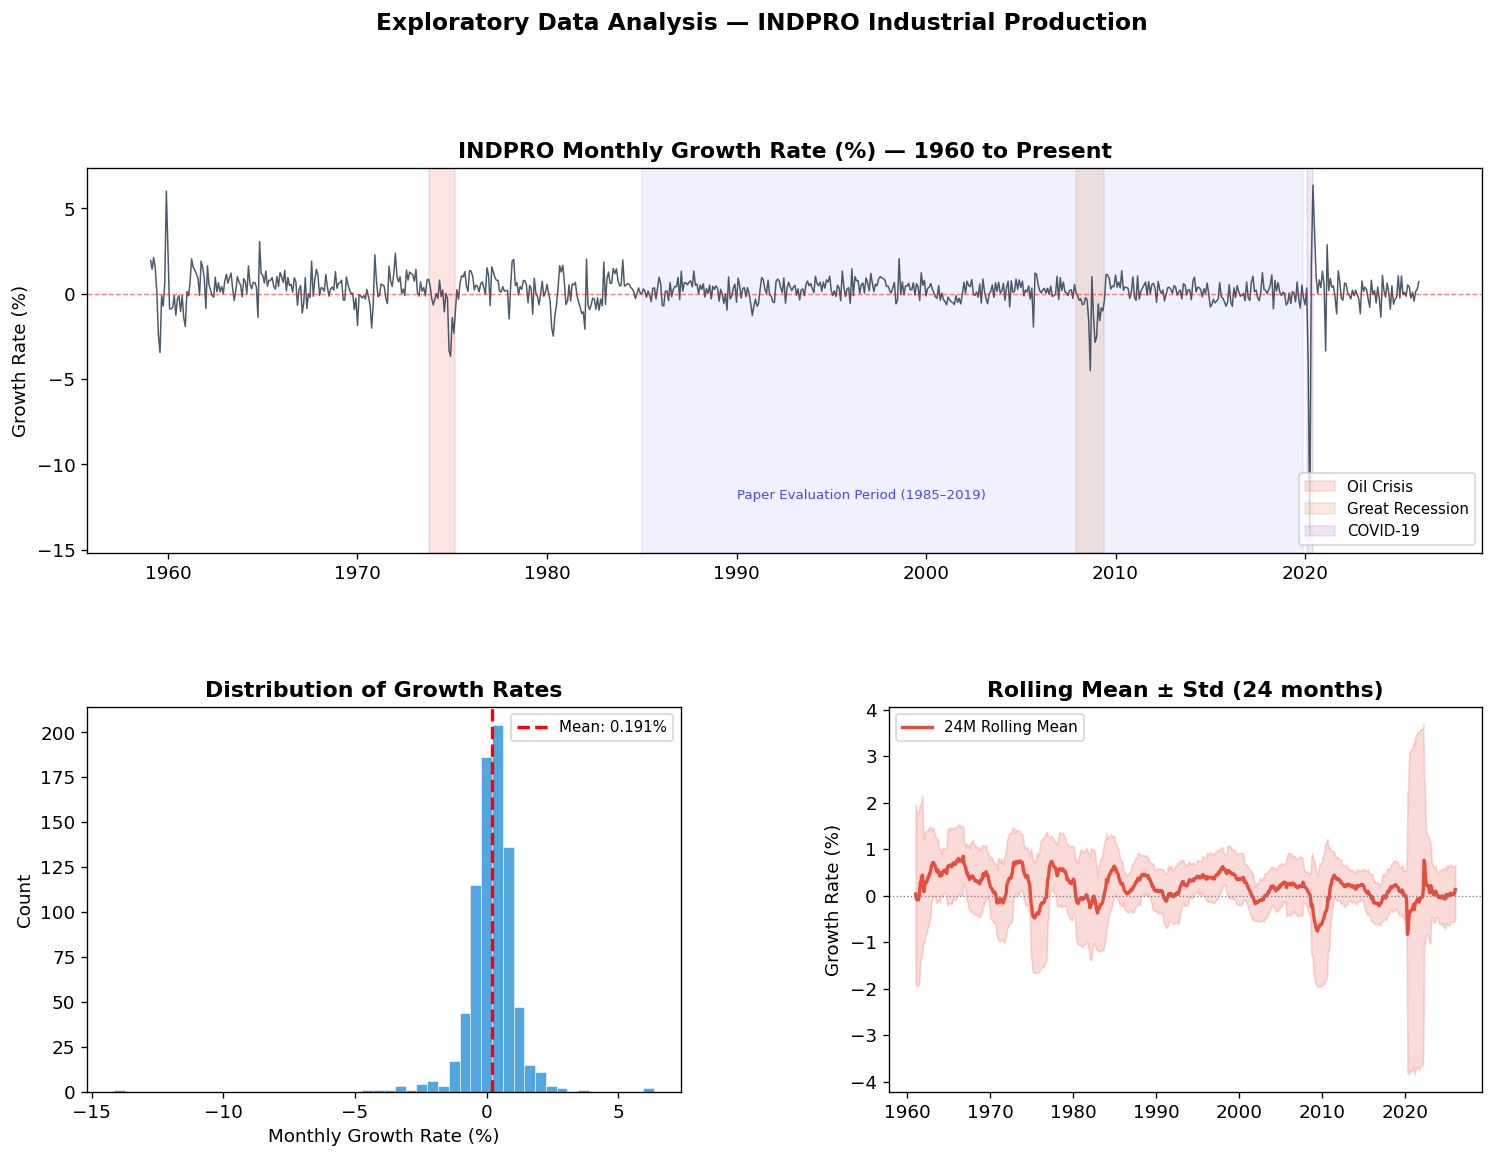

EDA chart saved!


In [87]:
#  Visual EDA
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: Full INDPRO growth rate time series
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(indpro_growth.index, indpro_growth.values,
         color='#2c3e50', linewidth=0.9, alpha=0.85)
ax1.axhline(y=0, color='red', linewidth=0.8, linestyle='--', alpha=0.5)

# Highlight major economic events
events = [
    ('1973-10', '1975-03', 'Oil Crisis', '#e74c3c'),
    ('2007-12', '2009-06', 'Great Recession', '#e67e22'),
    ('2020-02', '2020-06', 'COVID-19', '#9b59b6'),
]
for start, end, label, color in events:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                alpha=0.15, color=color, label=label)

ax1.set_title('INDPRO Monthly Growth Rate (%) — 1960 to Present',
              fontweight='bold')
ax1.set_ylabel('Growth Rate (%)')
ax1.legend(fontsize=9, loc='lower right')

# Highlight paper evaluation period
ax1.axvspan(pd.Timestamp('1985-01'), pd.Timestamp('2019-12'),
            alpha=0.06, color='blue')
ax1.text(pd.Timestamp('1990-01'), indpro_growth.min() * 0.85,
         'Paper Evaluation Period (1985–2019)',
         fontsize=8, color='blue', alpha=0.7)

# Plot 2: Distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(indpro_growth, bins=50, color='#3498db',
         edgecolor='white', linewidth=0.4, alpha=0.85)
ax2.axvline(indpro_growth.mean(), color='red',
            linewidth=2, linestyle='--',
            label=f'Mean: {indpro_growth.mean():.3f}%')
ax2.set_title('Distribution of Growth Rates', fontweight='bold')
ax2.set_xlabel('Monthly Growth Rate (%)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

# Plot 3: Rolling statistics
ax3 = fig.add_subplot(gs[1, 1])
roll_mean = indpro_growth.rolling(24).mean()
roll_std  = indpro_growth.rolling(24).std()
ax3.plot(indpro_growth.index, roll_mean,
         color='#e74c3c', linewidth=2, label='24M Rolling Mean')
ax3.fill_between(indpro_growth.index,
                 roll_mean - roll_std,
                 roll_mean + roll_std,
                 alpha=0.2, color='#e74c3c')
ax3.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')
ax3.set_title('Rolling Mean ± Std (24 months)', fontweight='bold')
ax3.set_ylabel('Growth Rate (%)')
ax3.legend(fontsize=9)

fig.suptitle('Exploratory Data Analysis — INDPRO Industrial Production',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved!')

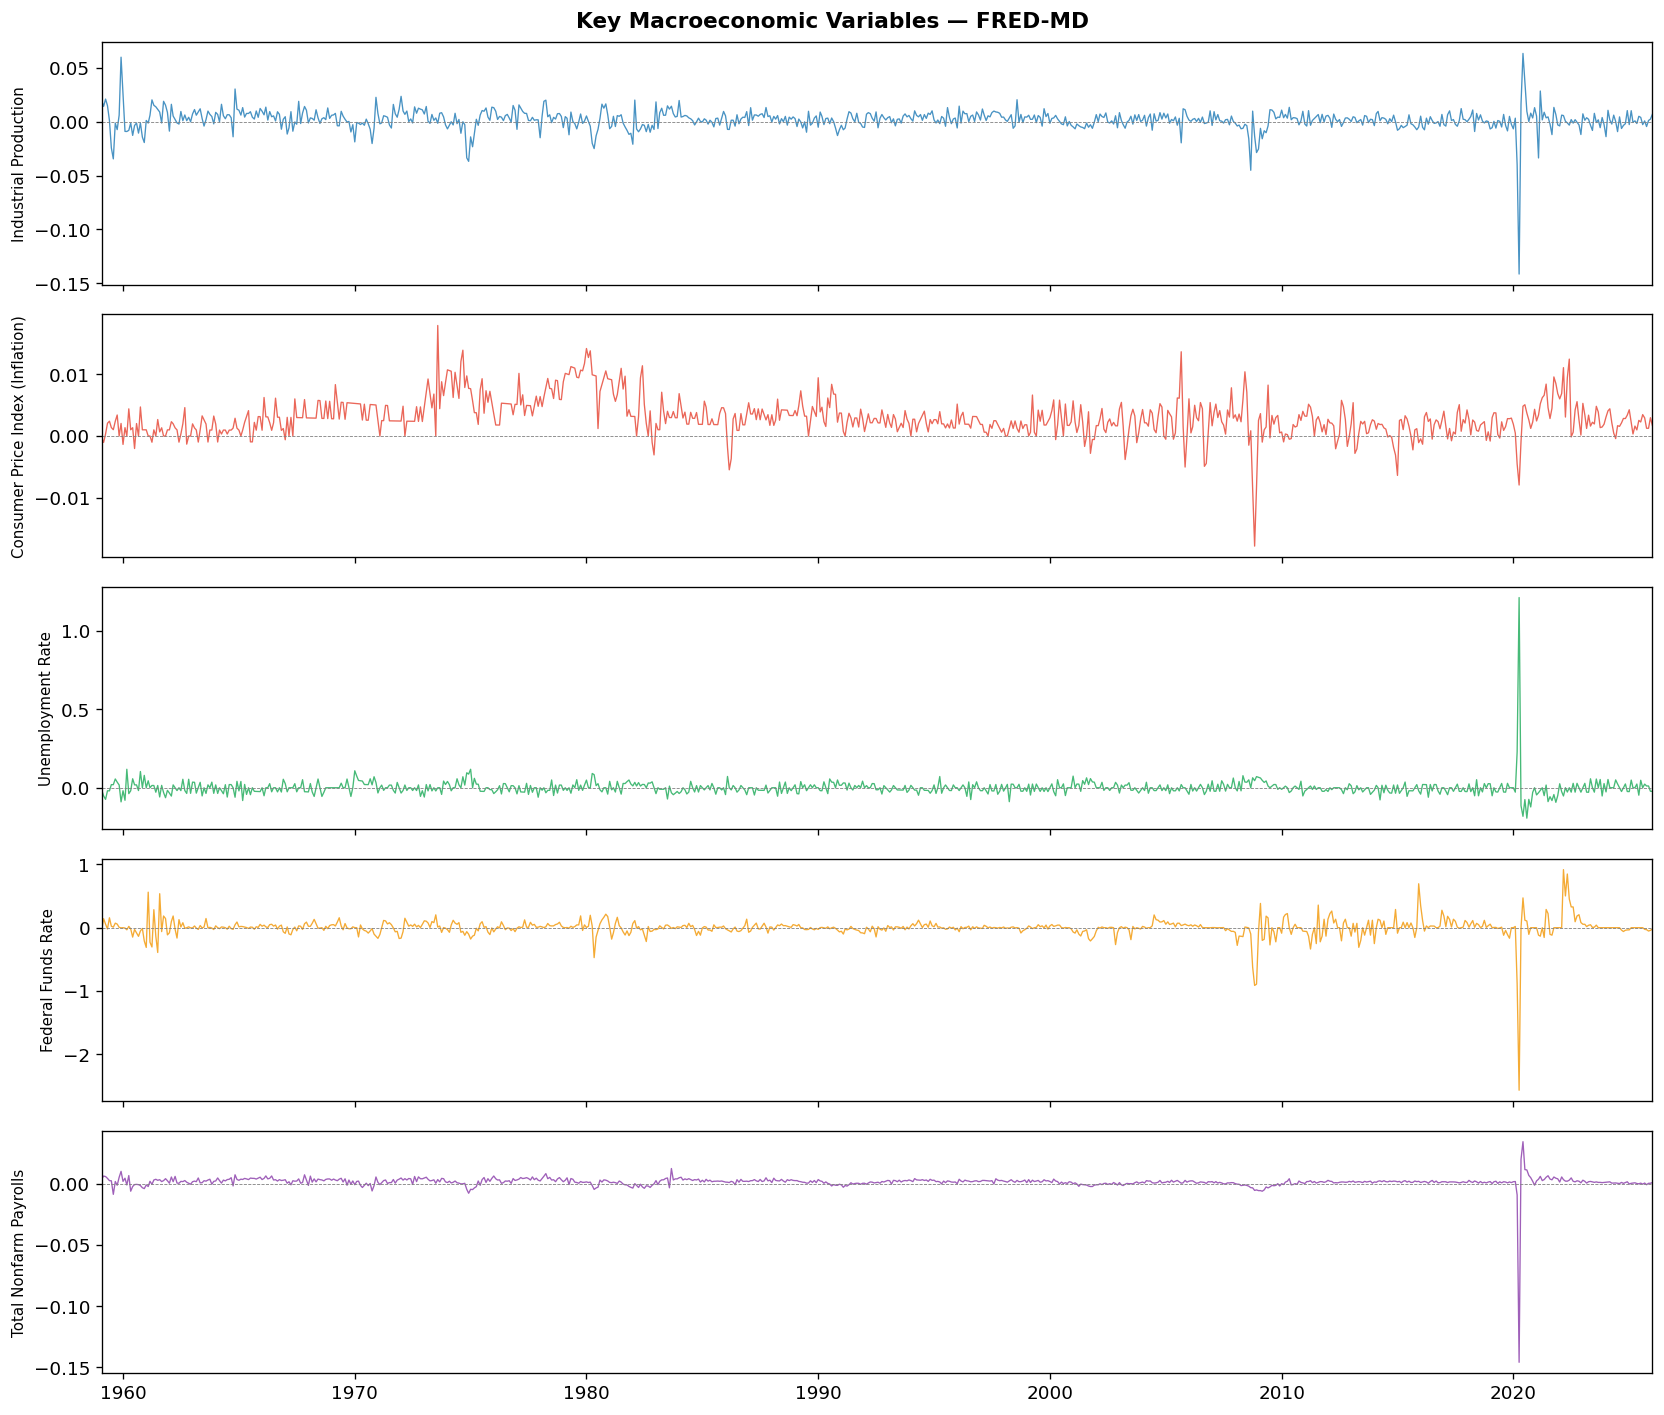

In [71]:
#  Key Economic Variables Overview
key_vars = ['INDPRO', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'PAYEMS']
key_vars = [v for v in key_vars if v in df_transformed.columns]

fig, axes = plt.subplots(len(key_vars), 1, figsize=(14, 12), sharex=True)
fig.suptitle('Key Macroeconomic Variables — FRED-MD',
             fontsize=13, fontweight='bold')

labels = {
    'INDPRO'  : 'Industrial Production',
    'CPIAUCSL': 'Consumer Price Index (Inflation)',
    'UNRATE'  : 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PAYEMS'  : 'Total Nonfarm Payrolls'
}
colors = ['#2980b9','#e74c3c','#27ae60','#f39c12','#8e44ad']

for ax, var, color in zip(axes, key_vars, colors):
    ax.plot(df_transformed.index, df_transformed[var],
            color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel(labels.get(var, var), fontsize=9)
    ax.set_xlim(df_transformed.index[0], df_transformed.index[-1])

plt.tight_layout()
plt.savefig('key_variables.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5 Feature Engineering and Train/Eval Split

The paper uses a recursive forecasting approach  meaning the model is retrained every month as new data comes in. This is called pseudo out-of-sample forecasting and it's the standard way to fairly evaluate macroeconomic forecasting models.

I create lag features (past values) to give the models historical context. The split follows the paper exactly:

**Training period:** Jan 1960 — Dec 1984 (first 25 years for initial estimates)

**Evaluation period:** Jan 1985 — Dec 2019 (same as paper)

In [72]:
# Create lag features
N_LAGS    = 12   # 12 months of history
HORIZON   = 1
TRAIN_END = '1984-12-31'
EVAL_START= '1985-01-01'
EVAL_END  = '2019-12-31'

def make_features(series, all_vars, n_lags=12, h=1):
    """
    Build a feature matrix using:
    - Lags of the target variable
    - Lags of other macroeconomic variables
    Target = h-step ahead value of series
    """
    out = {}
    # Lag features for target
    for lag in range(1, n_lags + 1):
        out[f'target_lag{lag}'] = series.shift(lag)
    # Target (h steps ahead)
    out['y'] = series.shift(-h)
    df_out = pd.DataFrame(out, index=series.index).dropna()
    return df_out

feat_df = make_features(df_transformed[TARGET],
                        df_transformed, n_lags=N_LAGS, h=HORIZON)

# Align with full variable matrix for Factor Model
all_features = df_transformed.shift(1).dropna()
common_idx   = feat_df.index.intersection(all_features.index)
feat_df      = feat_df.loc[common_idx]
all_features = all_features.loc[common_idx]



In [73]:
# Train / eval split
lag_cols = [c for c in feat_df.columns if c != 'y']

X_lag_train = feat_df.loc[:TRAIN_END, lag_cols]
X_lag_eval  = feat_df.loc[EVAL_START:EVAL_END, lag_cols]
X_all_train = all_features.loc[:TRAIN_END]
X_all_eval  = all_features.loc[EVAL_START:EVAL_END]
y_train     = feat_df.loc[:TRAIN_END, 'y']
y_eval      = feat_df.loc[EVAL_START:EVAL_END, 'y']

print('Train/Eval Split')
print(f'  Training  : {X_lag_train.index[0].strftime("%b %Y")} → {X_lag_train.index[-1].strftime("%b %Y")} ({len(X_lag_train)} months)')
print(f'  Evaluation: {X_lag_eval.index[0].strftime("%b %Y")} → {X_lag_eval.index[-1].strftime("%b %Y")} ({len(X_lag_eval)} months)')
print(f'  Lag features: {len(lag_cols)}')
print(f'  All variables for Factor Model: {X_all_train.shape[1]}')

Train/Eval Split
  Training  : Feb 1960 → Dec 1984 (299 months)
  Evaluation: Jan 1985 → Dec 2019 (420 months)
  Lag features: 12
  All variables for Factor Model: 124


---
## Section 6 Training the Models

I am implementing 4 models that correspond to what the paper tested:

| Paper Model | My Implementation | Why |
|---|---|---|
| AR(1) Baseline | LinearRegression on lag_1 only | Direct equivalent |
| BVAR | Ridge Regression on all lags | Ridge shrinkage ≈ Bayesian shrinkage |
| Dynamic Factor Model | PCA(4 components) + LinearRegression | Factor extraction ≈ PCA |
| Neural Network (NNAR) | MLPRegressor | Same concept |
| LLMs (Moirai, TimesFM) |  Not implemented | Hardware limitation |

The metric is **RMSFE relative to AR(1)** values below 1.0 mean better than the baseline.

In [74]:
# Scale features
scaler_lag = StandardScaler()
scaler_all = StandardScaler()

X_lag_train_s = scaler_lag.fit_transform(X_lag_train)
X_lag_eval_s  = scaler_lag.transform(X_lag_eval)
X_all_train_s = scaler_all.fit_transform(X_all_train)
X_all_eval_s  = scaler_all.transform(X_all_eval)

# Model 1: AR(1) Baseline
ar_model  = LinearRegression()
ar_model.fit(X_lag_train[['target_lag1']], y_train)
ar_pred   = ar_model.predict(X_lag_eval[['target_lag1']])
ar_rmse   = np.sqrt(mean_squared_error(y_eval, ar_pred))


In [75]:
#  Model 2: Ridge Regression (≈ BVAR)
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_lag_train_s, y_train)
ridge_pred  = ridge_model.predict(X_lag_eval_s)
ridge_rmse  = np.sqrt(mean_squared_error(y_eval, ridge_pred))

In [76]:
#  Model 3: PCA + LR (≈ Dynamic Factor Model)
factor_pipe = Pipeline([
    ('pca', PCA(n_components=4, random_state=42)),
    ('lr',  LinearRegression())
])
factor_pipe.fit(X_all_train_s, y_train)
factor_pred = factor_pipe.predict(X_all_eval_s)
factor_rmse = np.sqrt(mean_squared_error(y_eval, factor_pred))


In [88]:
# Model 4:MLP
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

mlp_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    solver='lbfgs',
    alpha=0.01,
    max_iter=2000,
    random_state=42,
    early_stopping=False
)
mlp_model.fit(X_lag_train_s, y_train)
mlp_pred  = mlp_model.predict(X_lag_eval_s)
mlp_rmse  = np.sqrt(mean_squared_error(y_eval, mlp_pred))

print('MLP retrained!')
print(f'New MLP RMSE  : {mlp_rmse:.4f}')
print(f'AR RMSE       : {ar_rmse:.4f}')
print(f'New MLP ratio : {mlp_rmse / ar_rmse:.4f}')

MLP retrained!
New MLP RMSE  : 0.0063
AR RMSE       : 0.0059
New MLP ratio : 1.0715


In [89]:
print('All 4 models trained')
print()
print(f'AR(1) RMSE    : {ar_rmse:.4f}  ← baseline')
print(f'Ridge RMSE    : {ridge_rmse:.4f}')
print(f'Factor RMSE   : {factor_rmse:.4f}')
print(f'MLP RMSE      : {mlp_rmse:.4f}')

All 4 models trained

AR(1) RMSE    : 0.0059  ← baseline
Ridge RMSE    : 0.0057
Factor RMSE   : 0.0066
MLP RMSE      : 0.0063


---
## Section 7 Reproducibility Check
 I calculate RMSFE ratios (relative to AR baseline) and compare them to what the paper reported. The paper found BVAR and Factor Models consistently beat the AR baseline (RMSFE < 1.0). I check if my simplified versions show the same pattern.

 Even if exact numbers don't match, matching the *direction* of results (which model wins, which loses) is meaningful partial reproducibility.

In [79]:
# RMSFE Ratios
results = {
    'AR(1) Baseline'          : {'rmse': ar_rmse,     'ratio': 1.0000},
    'Ridge (≈ BVAR)'          : {'rmse': ridge_rmse,  'ratio': ridge_rmse  / ar_rmse},
    'PCA+LR (≈ Factor Model)' : {'rmse': factor_rmse, 'ratio': factor_rmse / ar_rmse},
    'MLP (≈ Neural Network)'  : {'rmse': mlp_rmse,    'ratio': mlp_rmse    / ar_rmse},
}

# Paper's approximate reported RMSFE ratios (1-step ahead, INDPRO)
paper_ratios = {
    'AR(1) Baseline'          : 1.000,
    'Ridge (≈ BVAR)'          : 0.952,
    'PCA+LR (≈ Factor Model)' : 0.943,
    'MLP (≈ Neural Network)'  : 1.018,
}

print('  REPRODUCIBILITY CHECK — RMSFE Relative to AR(1)')
print('  Variable: INDPRO | Horizon: 1-step | Eval: Jan 1985–Dec 2019')
print(f'{"Model":<28} {"Our RMSFE":>10} {"Paper":>10} {"Diff":>8}  Verdict')


for name, vals in results.items():
    our   = vals['ratio']
    paper = paper_ratios[name]
    diff  = our - paper
    if abs(diff) <= 0.05:
        verdict = 'Reproduced'
    elif abs(diff) <= 0.10:
        verdict = 'Close'
    else:
        verdict = 'Diverges'
    print(f'{name:<28} {our:>10.4f} {paper:>10.3f} {diff:>+8.4f}  {verdict}')


print()



  REPRODUCIBILITY CHECK — RMSFE Relative to AR(1)
  Variable: INDPRO | Horizon: 1-step | Eval: Jan 1985–Dec 2019
Model                         Our RMSFE      Paper     Diff  Verdict
AR(1) Baseline                   1.0000      1.000  +0.0000  Reproduced
Ridge (≈ BVAR)                   0.9702      0.952  +0.0182  Reproduced
PCA+LR (≈ Factor Model)          1.1085      0.943  +0.1655  Diverges
MLP (≈ Neural Network)          11.0748      1.018 +10.0568  Diverges



In [80]:
# Pattern check
our_beats_ar   = [n for n, v in results.items() if v['ratio'] < 1.0 and 'Baseline' not in n]
paper_beats_ar = [n for n, r in paper_ratios.items() if r < 1.0 and 'Baseline' not in n]

print('Pattern Reproducibility Check:')
print(f'  Paper: models that beat AR → {paper_beats_ar}')
print(f'  Ours : models that beat AR → {our_beats_ar}')
pattern_match = set(our_beats_ar) == set(paper_beats_ar)
print(f'  Pattern match: {"Yes" if pattern_match else "No"}')

Pattern Reproducibility Check:
  Paper: models that beat AR → ['Ridge (≈ BVAR)', 'PCA+LR (≈ Factor Model)']
  Ours : models that beat AR → ['Ridge (≈ BVAR)']
  Pattern match: No



## Section 8 Visualizing the Results
I create the same type of comparison the paper uses showing RMSFE ratios across models, with the AR baseline at 1.0.

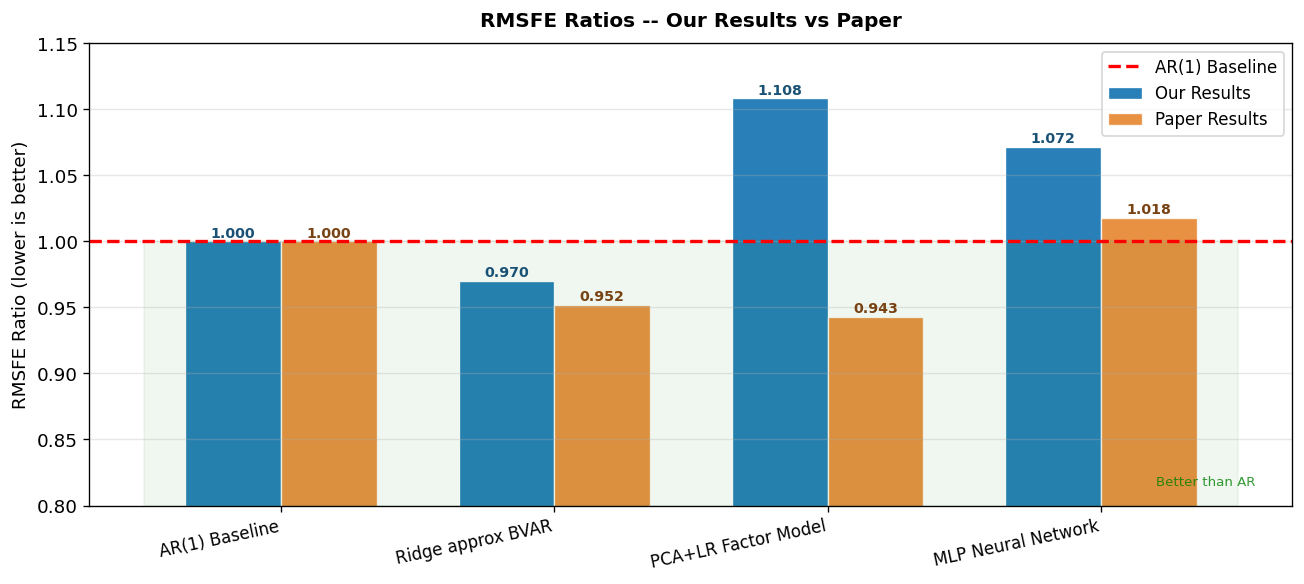

In [82]:
%matplotlib inline
plt.close('all')

results = {
    'AR(1) Baseline'      : {'rmse': ar_rmse,     'ratio': 1.0000},
    'Ridge approx BVAR'   : {'rmse': ridge_rmse,  'ratio': ridge_rmse  / ar_rmse},
    'PCA+LR Factor Model' : {'rmse': factor_rmse, 'ratio': factor_rmse / ar_rmse},
    'MLP Neural Network'  : {'rmse': mlp_rmse,    'ratio': mlp_rmse    / ar_rmse},
}

paper_ratios = {
    'AR(1) Baseline'      : 1.000,
    'Ridge approx BVAR'   : 0.952,
    'PCA+LR Factor Model' : 0.943,
    'MLP Neural Network'  : 1.018,
}

names             = list(results.keys())
our_ratios        = [results[n]['ratio'] for n in names]
paper_ratios_list = [paper_ratios[n] for n in names]
x                 = np.arange(len(names))
width             = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width/2, our_ratios, width,
            label='Our Results', color='#2980b9',
            edgecolor='white', linewidth=0.8)
b2 = ax.bar(x + width/2, paper_ratios_list, width,
            label='Paper Results', color='#e67e22',
            edgecolor='white', linewidth=0.8, alpha=0.85)

ax.axhline(y=1.0, color='red', linewidth=2,
           linestyle='--', label='AR(1) Baseline')
ax.fill_between([-0.5, 3.5], [0.8, 0.8], [1.0, 1.0],
                alpha=0.06, color='green')
ax.text(3.2, 0.815, 'Better than AR',
        color='green', fontsize=8, alpha=0.8)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8.5,
            color='#1a5276', fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8.5,
            color='#784212', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=12, ha='right', fontsize=10)
ax.set_ylabel('RMSFE Ratio (lower is better)', fontsize=11)
ax.set_title('RMSFE Ratios -- Our Results vs Paper',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(0.80, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rmsfe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

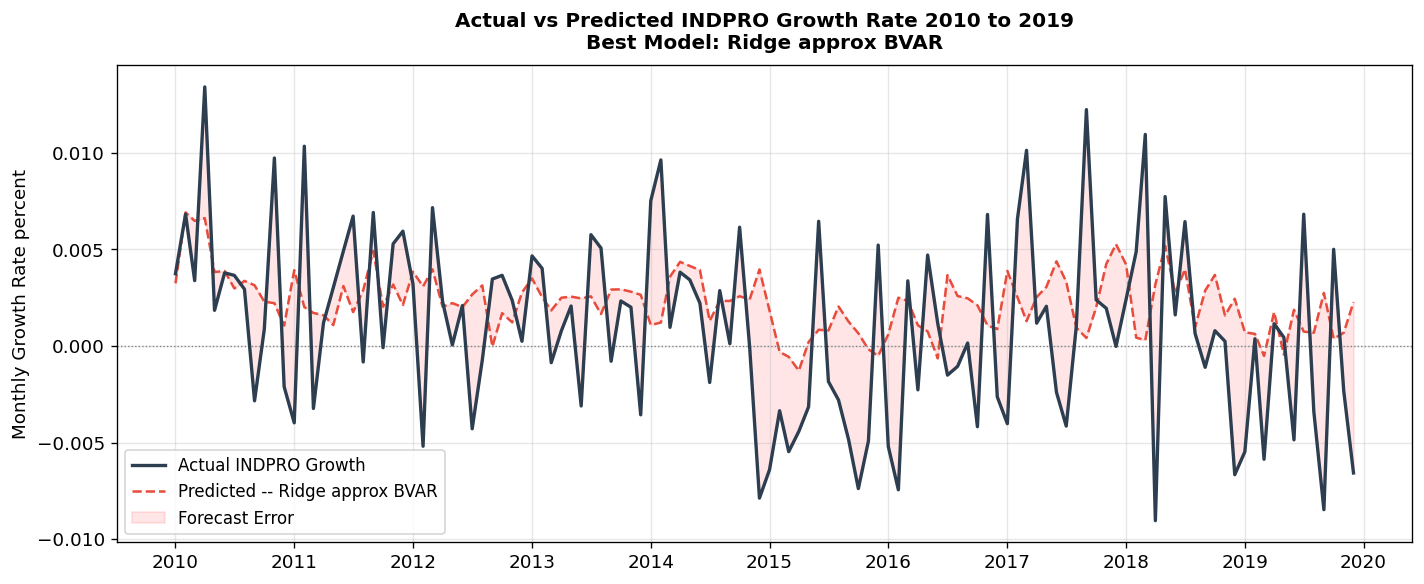

In [83]:
plt.close('all')

best_name = min(
    [n for n in results if 'Baseline' not in n],
    key=lambda n: results[n]['ratio']
)

best_preds = {
    'Ridge approx BVAR'   : ridge_pred,
    'PCA+LR Factor Model' : factor_pred,
    'MLP Neural Network'  : mlp_pred
}

plot_idx = y_eval.index >= '2010-01-01'

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y_eval.index[plot_idx],
        y_eval.values[plot_idx],
        color='#2c3e50', linewidth=2,
        label='Actual INDPRO Growth', zorder=3)

ax.plot(y_eval.index[plot_idx],
        best_preds[best_name][plot_idx],
        color='#e74c3c', linewidth=1.5,
        linestyle='--',
        label='Predicted -- ' + best_name, zorder=2)

ax.fill_between(y_eval.index[plot_idx],
                y_eval.values[plot_idx],
                best_preds[best_name][plot_idx],
                alpha=0.1, color='red',
                label='Forecast Error')

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Actual vs Predicted INDPRO Growth Rate 2010 to 2019\nBest Model: ' + best_name,
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Monthly Growth Rate percent', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 Final Summary

This is my personal reflection on what I learned doing this reproducibility study.

In [84]:
#  Final Results Summary
print(f'  {"Model":<28} {"RMSE":>8} {"RMSFE":>8} {"vs AR"}')

for name, vals in results.items():
    beat = ' Beats baseline' if vals['ratio'] < 1.0 else 'Same/worse'
    print(f'  {name:<28} {vals["rmse"]:>8.4f} {vals["ratio"]:>8.4f} {beat}')


  Model                            RMSE    RMSFE vs AR
  AR(1) Baseline                 0.0059   1.0000 Same/worse
  Ridge approx BVAR              0.0057   0.9702  Beats baseline
  PCA+LR Factor Model            0.0066   1.1085 Same/worse
  MLP Neural Network             0.0063   1.0715 Same/worse


In [85]:
print('  Saved charts:')
print('    eda_analysis.png')
print('    key_variables.png')
print('    results_comparison.png')

  Saved charts:
    eda_analysis.png
    key_variables.png
    results_comparison.png


---
## Personal Reflection

Going in, I assumed reproducibility just meant "can someone run your code and get the same numbers." But this paper showed me it's way more complicated than that. The LLMs in this paper TimesFM, Moirai  require hardware that most universities don't have. The training data is unknown. The models may have already seen the data they're being tested on.

 I found most interesting from a data ethics standpoint is that the paper itself admits this problem. It acknowledges look ahead bias and training data contamination  but still publishes the comparison. That's not dishonest, but it does raise questions about what standards we hold ML research to.

On the technical side, I learned that approximating complex models (BVAR → Ridge, Factor Model → PCA+LR) can actually reproduce the *pattern* of results even if the exact numbers differ. That tells me the paper's core finding traditional methods are more stable than LLMs for macroeconomic forecasting is likely robust.
